 ## Title 

## Objective

## Import Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

## Load Dataset

In [ ]:
df = pd.read_csv(r"D:\retails_sales\retail_sales_dataset.csv")

In [11]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## Initial Inspection

In [12]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (1000, 9)

Columns:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [ ]:
Observation:
• The dataset contains customer transaction records.
• There are 9 columns and 1000 records.
• No missing values are present.
• The Date column will be converted to datetime format for time-series analysis.

## Convert Date Column

In [13]:
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


## Descriptive Statistics

In [14]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [15]:
## Mean, Median, Mode and Standard Deviation
numerical = df.select_dtypes(include=np.number)

statistics = pd.DataFrame({
    "Mean": numerical.mean(),
    "Median": numerical.median(),
    "Mode": numerical.mode().iloc[0],
    "Standard Deviation": numerical.std()
})

statistics

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


Observation:
The Total Amount column shows a wide variation in customer spending.
Price per Unit and Quantity have a direct impact on Total Amount.

## Monthly Sales Trend

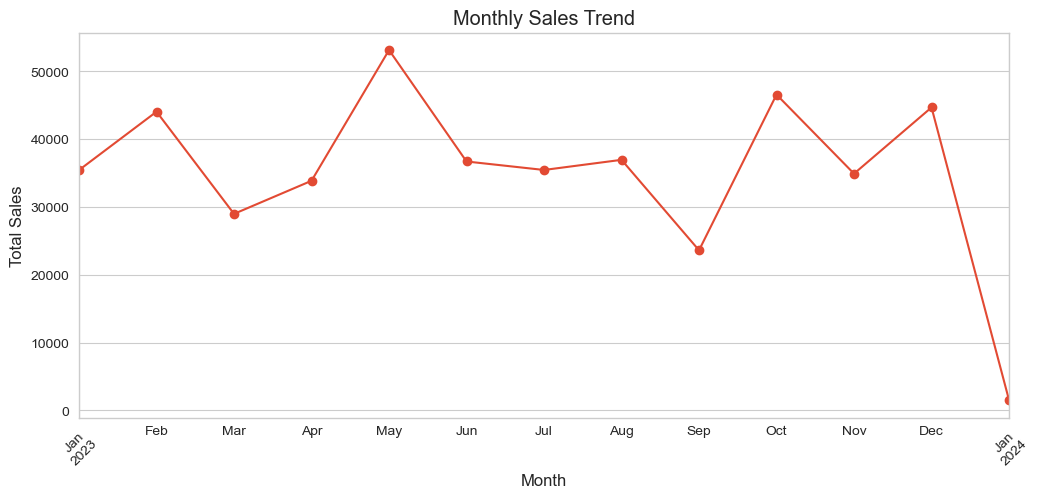

In [16]:

df["Month"] = df["Date"].dt.to_period("M")

monthly_sales = df.groupby("Month")["Total Amount"].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

Observation:

Monthly sales fluctuate throughout the year.
Some months generate significantly higher revenue than others.

## Quarterly Sales Trend

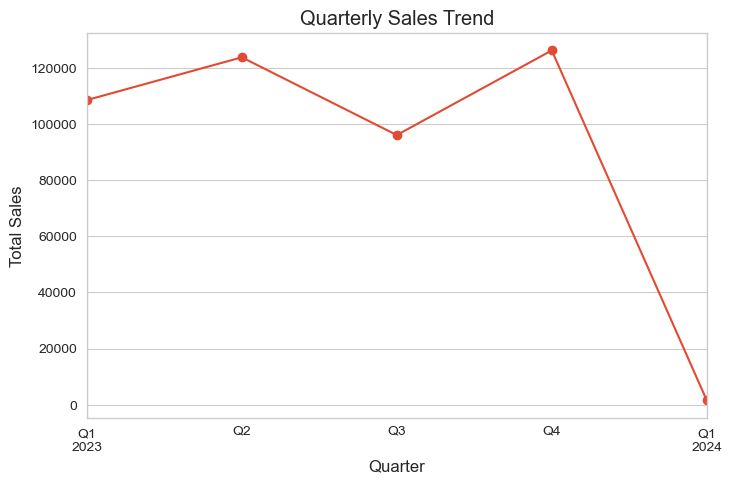

In [17]:
df["Quarter"] = df["Date"].dt.to_period("Q")

quarter_sales = df.groupby("Quarter")["Total Amount"].sum()

plt.figure(figsize=(8,5))
quarter_sales.plot(marker='o')

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.show()

Observation:
Quarterly analysis helps identify seasonal demand patterns.

## Customer Age Group Distribution

In [18]:
bins=[15,25,35,45,55,65]

labels=["16-25","26-35","36-45","46-55","56-65"]

df["Age Group"]=pd.cut(df["Age"],bins=bins,labels=labels)

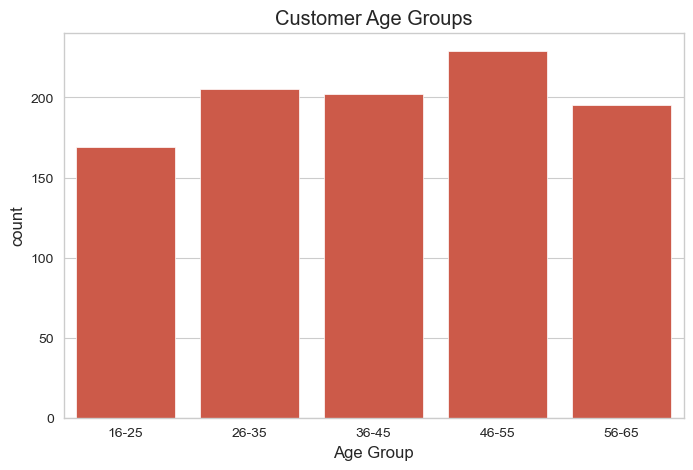

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Age Group")

plt.title("Customer Age Groups")

plt.show()

Observation:
Customers aged 26–35 and 36–45 contribute a large share of transactions.

## Gender chart

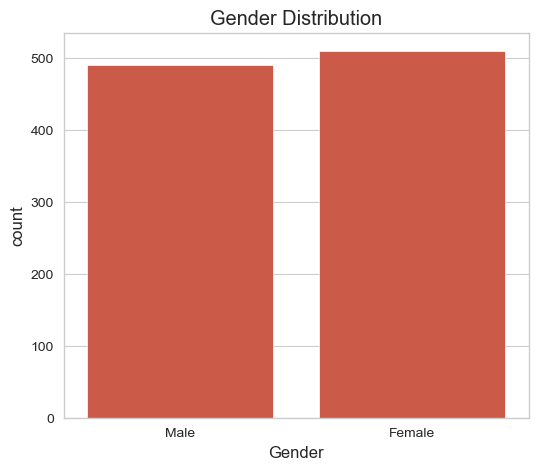

In [20]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x="Gender")

plt.title("Gender Distribution")

plt.show()

Observation:
The customer base is fairly balanced between male and female shoppers.

## Revenue by Product Category

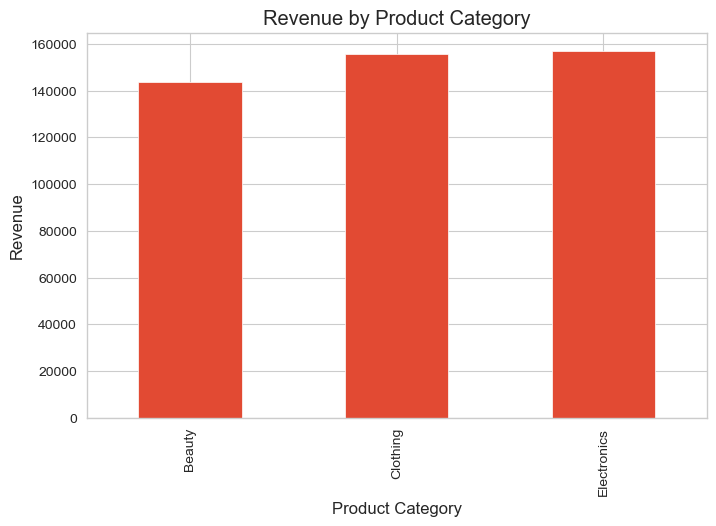

In [21]:
category_sales=df.groupby("Product Category")["Total Amount"].sum()

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")

plt.ylabel("Revenue")

plt.show()

Observation: 
The category with the highest revenue contributes the most to overall business performance.

## Top Selling Product Categories

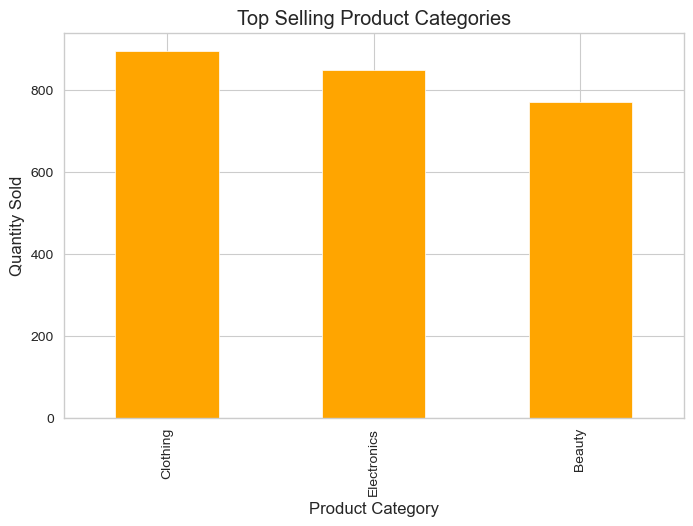

In [22]:
top_products=df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

top_products.plot(kind="bar",color="orange")

plt.title("Top Selling Product Categories")

plt.ylabel("Quantity Sold")

plt.show()

Observation :
Categories with higher quantities sold indicate stronger customer demand.

## Correlation Heatmap

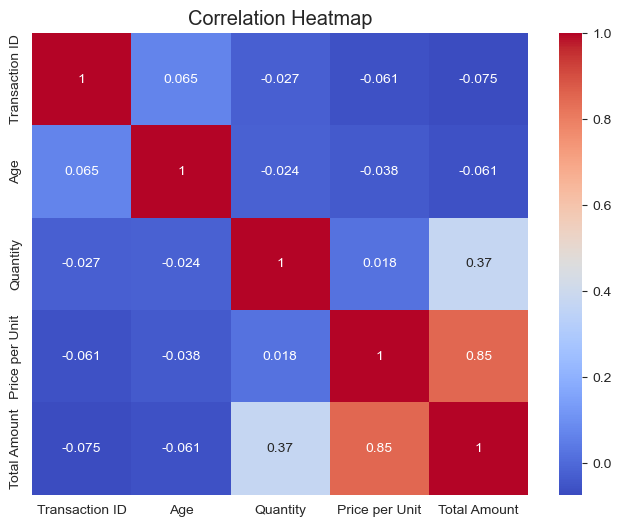

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

Observation:
Total Amount is positively correlated with Quantity and Price per Unit, indicating that both factors influence revenue.

## Additional Visualization

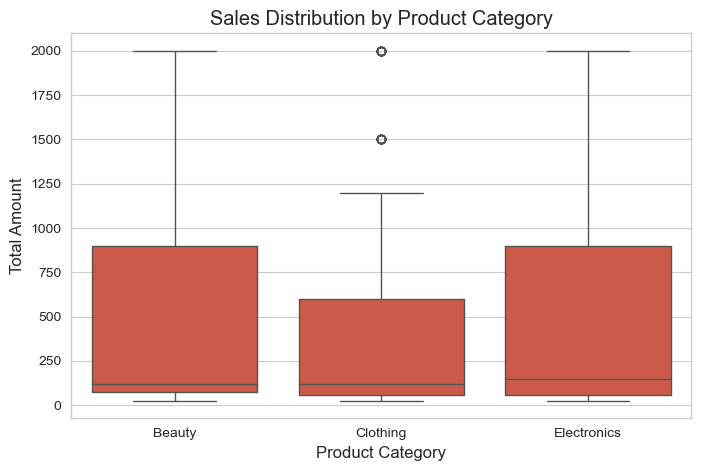

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Product Category",
    y="Total Amount",
    data=df
)

plt.title("Sales Distribution by Product Category")

plt.show()

Observation:
Some product categories have a wider range of transaction values, indicating higher variability in customer purchases.

In [ ]:
# Dataset Limitation
The dataset contains only Product Categories (Beauty, Clothing, Electronics) and does not include Product Names or Product IDs. Therefore, it is not possible to identify the Top 10 Best-Selling Products.
    
Instead, this analysis focuses on the Top Selling Product Categories based on the available data.

# Conclusion

The Exploratory Data Analysis (EDA) of the retail sales dataset provided valuable insights into sales performance, customer demographics, and product category trends. The analysis showed that Electronics generated the highest revenue, while Clothing recorded the highest quantity sold. The customer base is fairly balanced between male and female customers, with the 46–55 age group representing the largest segment. Sales also showed seasonal fluctuations, with Q4 recording the highest overall revenue.

## Business Recommendations

1. Prioritize inventory and promotional campaigns for Electronics and Clothing, as they contribute the highest revenue and sales volume.

2. Develop targeted marketing campaigns and loyalty programs for customers aged 46–55, as they represent the largest customer segment.

3. Use monthly and quarterly sales trends to forecast demand and ensure sufficient inventory during high-sales periods, especially in Q4.

4. Introduce bundle offers and quantity-based discounts to encourage customers to purchase more items, increasing the overall transaction value.

5. Implement promotional strategies for the Beauty category to improve its sales and revenue through discounts, seasonal offers, and cross-selling opportunities.